In [42]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-binomial-mix')
import betabinomo_mix_singlecells as bbmix
import cell_state_asign_consistency as cellassign

reload(bbmix)
reload(cellassign)

<module 'cell_state_asign_consistency' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-binomial-mix/cell_state_asign_consistency.py'>

In [43]:
# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import Leaflet_load_cluster_data_03 as llc 

### Human muscle data mixture model run

In [46]:
organ="Mammary_Gland"

In [47]:
# load any metadata that is available 
#import scanpy as sc
#adata = sc.read_h5ad("/gpfs/commons/datasets/controlled/CZI/tabula-sapiens/TS_figshare/TabulaSapiens.h5ad")
#metadata = adata.obs 
# filter first by organ_tissue
#metadata = metadata[metadata["organ_tissue"]==organ]
#metadata = metadata[["organ_tissue", "free_annotation", "cell_ontology_class", "compartment"]].drop_duplicates()
# drop index 
#metadata = metadata.reset_index(drop=True)
# rename cell_ontology_class to cell_type 
#metadata = metadata.rename(columns={"cell_ontology_class" : "cell_type"})
#metadata.head()

In [48]:
# save muscle metadata to file
#metadata.to_csv("/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/muscle_metadata.csv", index=False, header=True, sep="\t")
metadata = pd.read_csv("/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/muscle_metadata.csv", sep="\t")

In [49]:
# input_files_folder = '/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Muscle_Yes/'
# input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'
# input_files_folder = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/"
input_files_folder = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/"

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = llc.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=10000, remove_singletons=True, has_genes="yes") #, celltypes=cell_types) 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(final_data, **float_type)

# merge cell_ids_conversion with metadata to add more cell type information
# cell_ids_conversion = cell_ids_conversion.merge(metadata, on="cell_type")

simple_data_human = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  157665
Number of junctions after removing singletons:  47015
The number of unique cell types in the data is:  4
The number of unique cells in the data is:  2405
The number of unique junctions in the data is:  47016
The maximum junction count was initially:  251545
156
The maximum junction count is now:  9934
The number of junctions in the data is:  45664
The number of cells in the data is:  2405
The number of cell types in the data is:  4
The number of cells going into training data is:
2405
2405


In [50]:
print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))

The number of junctions is:  45664
The number of intron clusters observed is:  11726
The number of genes is:  7759


In [51]:
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(final_data, **float_type)

The number of cells going into training data is:
2405
2405


In [52]:
cell_ids_conversion['cell_type'].value_counts()

Mammary_Gland_basal_cell                                  1340
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland     578
Mammary_Gland_stromal_cell                                 440
Mammary_Gland_endothelial_cell                              47
Name: cell_type, dtype: int64

### Run Binomial mixture model!

In [85]:
torch.manual_seed(42)
np.random.seed(42)

K = 3

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1., 
    "pi_prior" : 1.
}

print(hypers["eta"])

cpu
0.3333333333333333


In [90]:
num_trials = 5 # should also be an argument that gets fed in
num_iters = 100 # should also be an argument that gets fed in
tol = 0.0001
print("The K used is: ", K)
results = [ bbmix.calculate_CAVI(K, my_data, float_type, hypers, init_labels = None, num_iterations = num_iters, tolerance=tol) 
           for t in range(num_trials) ]

The K used is:  3
Initialize VI params
Initializing variational parameters with N = 2405 cells and J = 45664 junctions
Got the initial ELBO ^
The tolerance is set to  0.0001
ELBO converged @ -909435328.0 CAVI iteration # 9 complete
ELBO converged @ -909435328.0 CAVI iteration # 9 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 2405 cells and J = 45664 junctions
Got the initial ELBO ^
The tolerance is set to  0.0001
ELBO converged @ -909440576.0 CAVI iteration # 7 complete
ELBO converged @ -909440576.0 CAVI iteration # 7 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 2405 cells and J = 45664 junctions
Got the initial ELBO ^
The tolerance is set to  0.0001
ELBO converged @ -909442176.0 CAVI iteration # 7 complete
ELBO converged @ -909442176.0 CAVI iteration # 7 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 2405 cells and J = 45664 junctions
Got the initial ELBO

### Consensus Clustering 

In [91]:
sum_matrices = cellassign.consensus_clustering(results)

# normalize by number of trials
normalized_matrix = sum_matrices / sum_matrices.max() # taking the sum_matrix and dividing by the max value in the matrix

# get distance metric 
distance_matrix = 1 - normalized_matrix

Got all cells and their assignments based on PHI_f in each trial!
Got a cell by cell matrix for each trial indicating whether cells were coassigned
Getting sum of matrices across all iterations


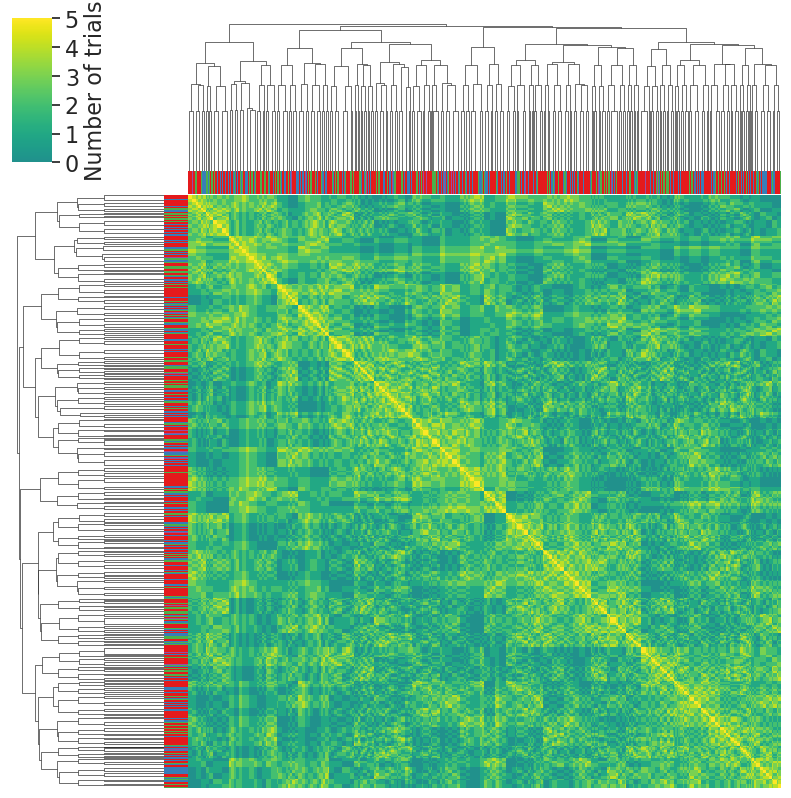

In [92]:
# plot heatmap 

num_samples = 1000
samp_indices = np.random.choice(cell_ids_conversion.shape[0], num_samples, replace=False)
cell_types_heatmap = cell_ids_conversion.iloc[samp_indices]

color_palette = sns.color_palette("Set1", n_colors=len(cell_types_heatmap['cell_type'].unique()))

# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_types_heatmap['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_types_heatmap.cell_type.values

cell_type_colors = dict(zip(unique_cell_types, colors))

# Convert cell types to corresponding colors for rows and columns
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]
col_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

cluster = sns.clustermap(
    data=sum_matrices[samp_indices,:][:,samp_indices],
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    xticklabels=False,
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    col_colors=col_colors,   # Apply column colors
        cbar_kws={'label': 'Number of trials'} # Split label over two lines here
    )

cluster.cax.set_ylabel('Number of trials', size=16)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(16)

plt.show()

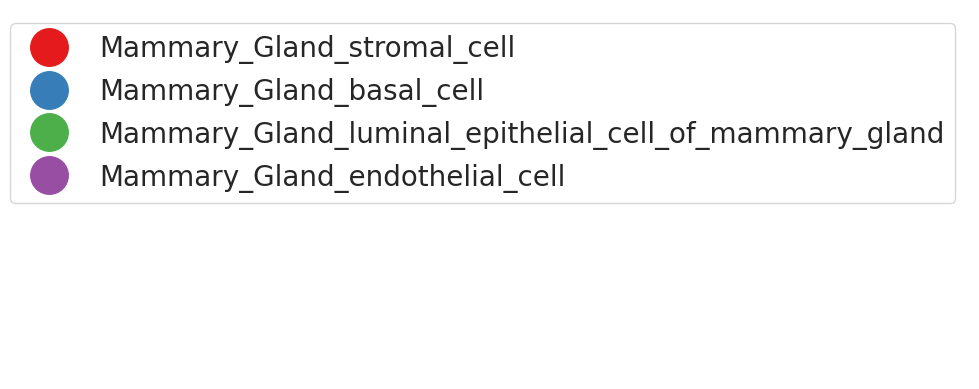

In [56]:
sns.set_style("white")

# Create the legend
for cell_type, color in cell_type_colors.items():
    plt.plot([], [], 'o', label=cell_type, color=color, markersize=27)  # Use 'o' to show the colors clearly

plt.legend(fontsize=20)
plt.axis('off')  # Turn off axis
plt.show()

### Evaluate the learned posteriors

The trial with the highest ELBO was 4


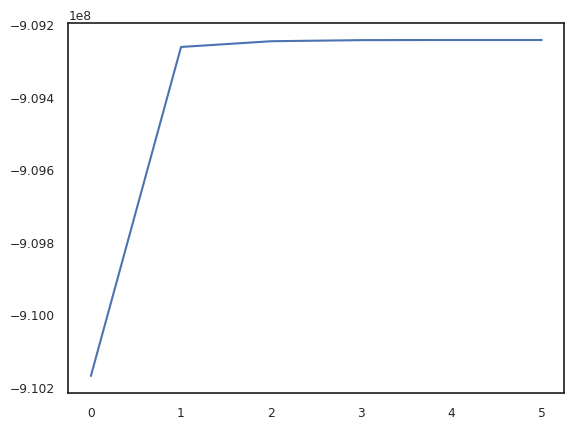

In [57]:
best = np.argmax([ g[-1][-1] for g in results ]) # final ELBO
print(f"The trial with the highest ELBO was {best}")
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
elbos_all = np.array(elbos_all)
plt.plot(elbos_all[1:]); plt.show()

In [58]:
cell_ids_conversion

,cell_id_index,cell_id,cell_type
6,0,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell
17029,1,A10-B000166-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell
39773,2,A10-B002433-3_38_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell
58704,3,A10-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell
93362,4,A10-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell
...,...,...,...
38830678,2400,P9-B002432-3_38_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell
38842981,2401,P9-B002433-3_38_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell
38856962,2402,P9-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell
38880113,2403,P9-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell


In [59]:
GAMMA_f

tensor([576.1441, 497.2018, 386.1980, 569.2576, 377.1986])

In [60]:
PHI_f_plot = pd.DataFrame(PHI_f.cpu().numpy())
PHI_f_plot['cell_id'] = cell_ids_conversion["cell_type"].to_numpy()

(array([9.619e+03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

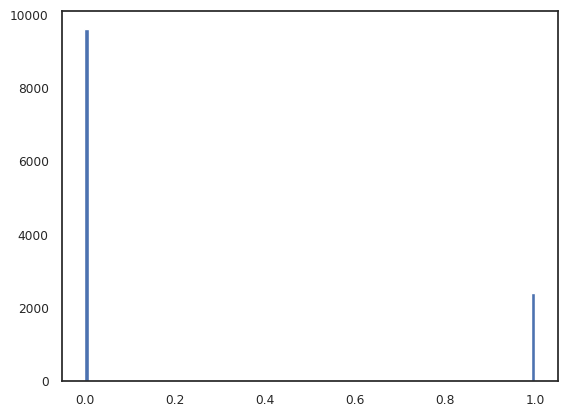

In [61]:
np.array(PHI_f.flatten())
# make histogram of the cell type proportions
plt.hist(np.array(PHI_f.flatten()), bins=100)

In [62]:
# How much is each cell state is used globally 

# Calculate the total sum of the tensor values
total_sum = torch.sum(GAMMA_f)

# Calculate the percentages
percentages = (GAMMA_f / total_sum) 
print(percentages)

# Convert the tensor to a dataframe 
GAMMA_f_plot = pd.DataFrame(percentages.cpu().numpy())
# Give it a colname called theta 
GAMMA_f_plot.columns = ["theta"]
GAMMA_f_plot["cell_state"] = GAMMA_f_plot.index
GAMMA_f_plot.sort_values(by="theta", ascending=False, inplace=True)
GAMMA_f_plot["new_cell_state"] = np.arange(GAMMA_f_plot.shape[0])

sorted_cell_states = GAMMA_f_plot["new_cell_state"].astype(str)

# rename cell_state to be from 0 to K-1 based on order in sorted_cell_states
GAMMA_f_plot

tensor([0.2395, 0.2067, 0.1605, 0.2366, 0.1568])


,theta,cell_state,new_cell_state
0,0.239461,0,0
3,0.236599,3,1
1,0.206651,1,2
2,0.160515,2,3
4,0.156774,4,4


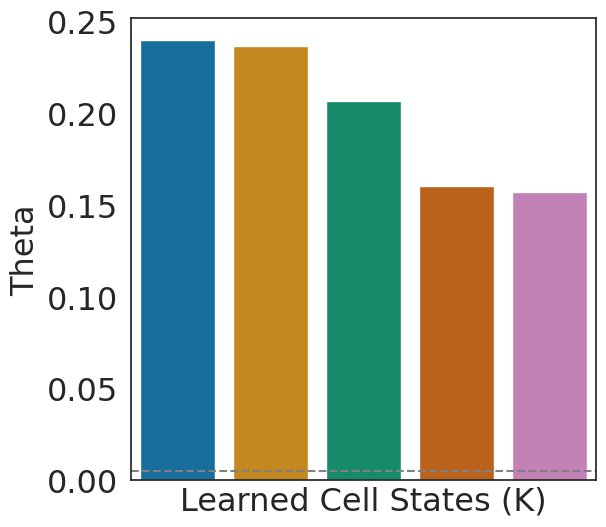

In [63]:
GAMMA_f_plot["new_cell_state"] = pd.Categorical(sorted_cell_states, sorted_cell_states.unique())
GAMMA_f_plot = GAMMA_f_plot.sort_values(by='new_cell_state')

# Create a color mapping for each unique cellassignment
unique_states = GAMMA_f_plot['new_cell_state'].unique()
palette = sns.color_palette("colorblind", len(unique_states))
color_mapping = dict(zip(unique_states, palette))

# Make barplot using sns
plt.figure(figsize=(6, 6))
sns.barplot(x="new_cell_state", y="theta", data=GAMMA_f_plot, palette=color_mapping)
plt.axhline(0.005, ls='--', color='grey')

# Make Y label say Theta and increase font of all labels and ticks
plt.ylabel("Theta", fontsize=23)
plt.xlabel("Learned Cell States (K)", fontsize=23)
plt.xticks([])
plt.yticks(fontsize=23)
plt.show()

In [64]:
cell_types_summary=cell_ids_conversion['cell_type'].value_counts()
cell_types_summary=pd.DataFrame(cell_types_summary)
cell_types_summary.reset_index(inplace=True)
cell_types_summary.columns=['cell_type','count']

# get percentage of each cell type in the data 
cell_types_summary['percentage']=cell_types_summary['count']/cell_types_summary['count'].sum()
cell_types_summary.sort_values(by='percentage',ascending=False,inplace=True)
print(cell_types_summary)

                                           cell_type  count  percentage
0                           Mammary_Gland_basal_cell   1340    0.557173
1  Mammary_Gland_luminal_epithelial_cell_of_mamma...    578    0.240333
2                         Mammary_Gland_stromal_cell    440    0.182952
3                     Mammary_Gland_endothelial_cell     47    0.019543


(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.1, '0.1'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5, '0.5'),
  Text(0, 0.6000000000000001, '0.6')])

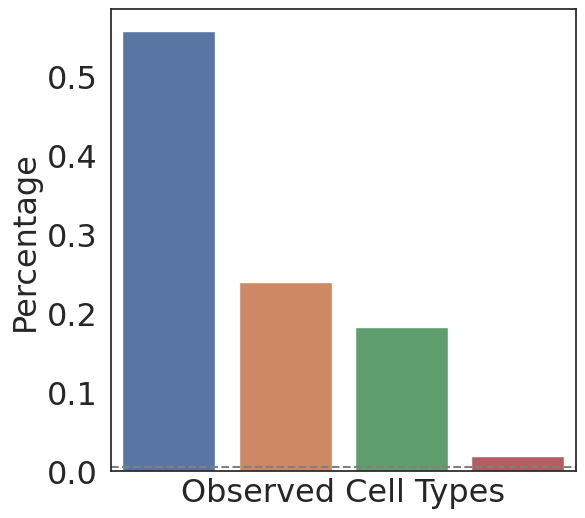

In [65]:
# Create the barplot using the cell_type_colors palette
plt.figure(figsize=(6, 6))
sns.barplot(x="cell_type", y="percentage", data=cell_types_summary)
plt.axhline(0.005, ls='--', color='grey')
plt.ylabel("Percentage", fontsize=23)
plt.xlabel("Observed Cell Types", fontsize=23)
plt.xticks([])
plt.yticks(fontsize=23)

In [66]:
# let's retain only the cell states that are used more than 1% of the time
#GAMMA_f_plot = GAMMA_f_plot[GAMMA_f_plot["theta"] > 0.005]
#GAMMA_f_plot.index.values

In [67]:
# convert PHI_f to a dataframe and add a column with cell ID and cell type 
PHI_f = pd.DataFrame(PHI_f)

# Keep only cell states defined above GAMMA_f_plot.index.values
PHI_f = PHI_f.loc[:, GAMMA_f_plot.index.values]
PHI_f

,0,3,1,2,4
0,0.000000e+00,0.0,1.0,0.0,0.0
1,0.000000e+00,0.0,0.0,1.0,0.0
2,0.000000e+00,1.0,0.0,0.0,0.0
3,1.000000e+00,0.0,0.0,0.0,0.0
4,0.000000e+00,1.0,0.0,0.0,0.0
...,...,...,...,...,...
2400,0.000000e+00,0.0,0.0,0.0,1.0
2401,1.000000e+00,0.0,0.0,0.0,0.0
2402,4.374006e-19,0.0,1.0,0.0,0.0
2403,0.000000e+00,1.0,0.0,0.0,0.0


In [68]:
# Add "CellState" to each column 
PHI_f.columns = ["CellState_" + str(i+1) for i in range(PHI_f.shape[1])]
PHI_f['cell_id'] = cell_ids_conversion.cell_id.values
PHI_f['cell_type'] = cell_ids_conversion.cell_type.values
PHI_f.groupby('cell_type').sum()

/scratch/ipykernel_39464/1031914918.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  PHI_f.groupby('cell_type').sum()


,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5
cell_type,,,,,
Mammary_Gland_basal_cell,361.944031,275.055786,250.001572,237.000000,215.998627
Mammary_Gland_endothelial_cell,18.000000,8.000000,9.000000,4.000000,8.000000
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland,69.000000,181.001816,184.000168,78.998016,65.000000
Mammary_Gland_stromal_cell,127.000038,105.000000,54.000000,65.999962,88.000000


/scratch/ipykernel_39464/1438057802.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  PHI_f.groupby('cell_type').sum()
/scratch/ipykernel_39464/1438057802.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sum_prop=PHI_f.groupby('cell_type').sum()/PHI_f.groupby('cell_type').count()


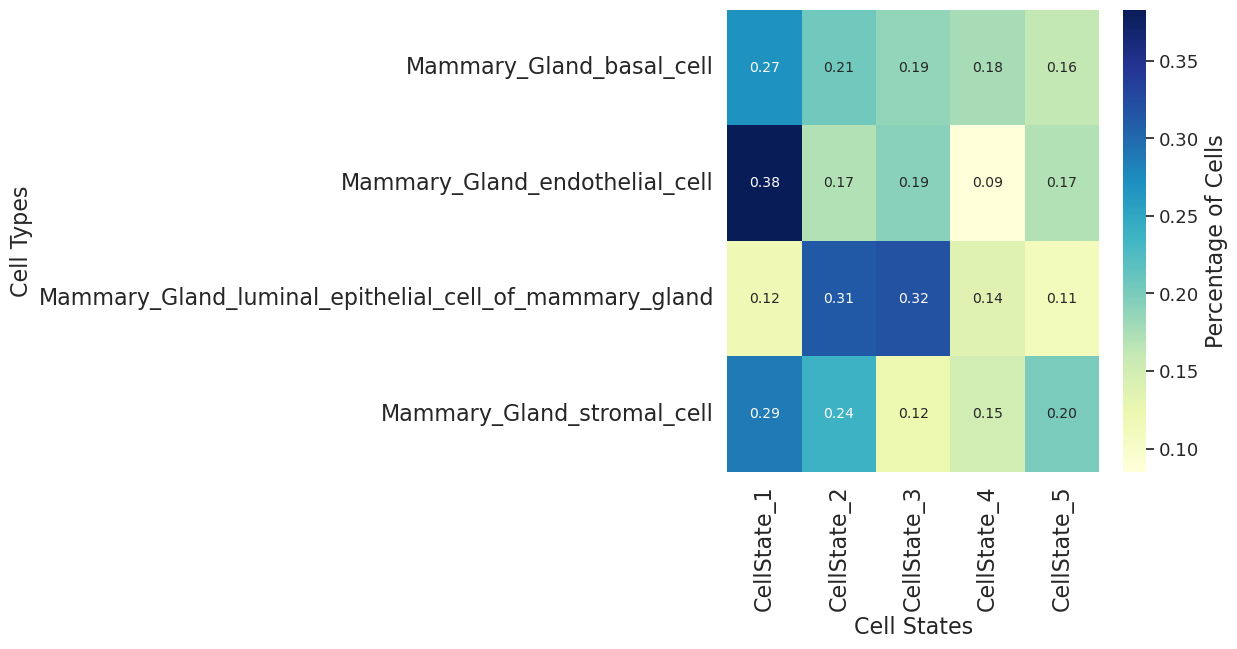

In [69]:
# group by cell_type and sum across each cellstate 
PHI_f.groupby('cell_type').sum()
sum_prop=PHI_f.groupby('cell_type').sum()/PHI_f.groupby('cell_type').count()
# remove cell_id column 
sum_prop=sum_prop.drop(columns=['cell_id'])
#masked_data = np.ma.masked_equal(sum_prop, 0)
sns.set(font_scale=0.8)  # Adjust font size for labels
# make figure bigger 
plt.figure(figsize=(6, 6))
# make font size of xtickts and yticks bigger
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)

ax = sns.heatmap(sum_prop, annot=True, cmap="YlGnBu", fmt='.2f', annot_kws={"size": 10}, cbar_kws={'label': 'Percentage of Cells'})

#labels = [label.get_text().replace("oligodendrocyte_precursor_cell", "oligodendrocyte_\nprecursor_cell") for label in ax.get_yticklabels()]
#ax.set_yticklabels(labels)

# Further visual modifications
xlabel = plt.xlabel("Cell States", fontsize=16)
ylabel = plt.ylabel("Cell Types", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Adjusting color bar settings
cbar = plt.gcf().axes[-1]
cbar.tick_params(labelsize=13)
cbar.set_ylabel('Percentage of Cells', fontsize=16)

plt.show()

In [70]:
# run fisher's exact test to see if the cell states are enriched for any cell types
from scipy.stats import fisher_exact

PHI_f_melt = pd.melt(PHI_f, id_vars=['cell_id', 'cell_type'], value_vars=PHI_f.columns[:-2])

# for each cell, choose cell state with highest probability
PHI_f_melt = PHI_f_melt.sort_values(by=['cell_id', 'value'], ascending=False).drop_duplicates(subset=['cell_id'])
PHI_f_melt.head()

,cell_id,cell_type,variable,value
2404,P9-B002438-3_38_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,CellState_1,1.0
4808,P9-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,CellState_2,1.0
7212,P9-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,CellState_3,1.0
2401,P9-B002433-3_38_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,CellState_1,1.0
12020,P9-B002432-3_38_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,CellState_5,1.0


In [71]:
# run fisher's exact test to test overall association between cell states and cell types
# contingency table

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(PHI_f_melt['variable'], PHI_f_melt['cell_type'])
contingency_table

chi2, pvalue, _, _ = chi2_contingency(contingency_table)
print(chi2, pvalue)
print(print("P-value: {:.50f}".format(pvalue)))

140.8373238408752 4.058038667712094e-24
P-value: 0.00000000000000000000000405803866771209385761195889
None


In [72]:
# change column names to only include cell type the thing aftert 'Myeloid_'
#contingency_table.columns = ['_'.join(x.split('_')[2:]) for x in contingency_table.columns]
contingency_table

cell_type,Mammary_Gland_basal_cell,Mammary_Gland_endothelial_cell,Mammary_Gland_luminal_epithelial_cell_of_mammary_gland,Mammary_Gland_stromal_cell
variable,,,,
CellState_1,362,18,69,127
CellState_2,275,8,181,105
CellState_3,250,9,184,54
CellState_4,237,4,79,66
CellState_5,216,8,65,88


In [73]:
# convert contingency table to proportions 
contingency_table = contingency_table / contingency_table.sum() # represents proportion of cells in cell type that is in cell state 
contingency_table

cell_type,Mammary_Gland_basal_cell,Mammary_Gland_endothelial_cell,Mammary_Gland_luminal_epithelial_cell_of_mammary_gland,Mammary_Gland_stromal_cell
variable,,,,
CellState_1,0.270149,0.382979,0.119377,0.288636
CellState_2,0.205224,0.170213,0.313149,0.238636
CellState_3,0.186567,0.191489,0.318339,0.122727
CellState_4,0.176866,0.085106,0.136678,0.150000
CellState_5,0.161194,0.170213,0.112457,0.200000


In [77]:
# reorder variable in contingency table cellstate10 should go after cellstate9
contingency_table = contingency_table.reindex(sorted(contingency_table.columns), axis=1)

ordered_indices = [
    'CellState_1', 'CellState_2', 'CellState_3', 'CellState_4',
    'CellState_5']

# Assuming your dataframe is called df
#ordered_indices = [
#    'CellState_1', 'CellState_2', 'CellState_3', 'CellState_4',
#    'CellState_5', 'CellState_6', 'CellState_7', 'CellState_8',
#    'CellState_9', 'CellState_10'
#]

contingency_table = contingency_table.reindex(ordered_indices)
contingency_table

cell_type,Mammary_Gland_basal_cell,Mammary_Gland_endothelial_cell,Mammary_Gland_luminal_epithelial_cell_of_mammary_gland,Mammary_Gland_stromal_cell
variable,,,,
CellState_1,0.270149,0.382979,0.119377,0.288636
CellState_2,0.205224,0.170213,0.313149,0.238636
CellState_3,0.186567,0.191489,0.318339,0.122727
CellState_4,0.176866,0.085106,0.136678,0.150000
CellState_5,0.161194,0.170213,0.112457,0.200000


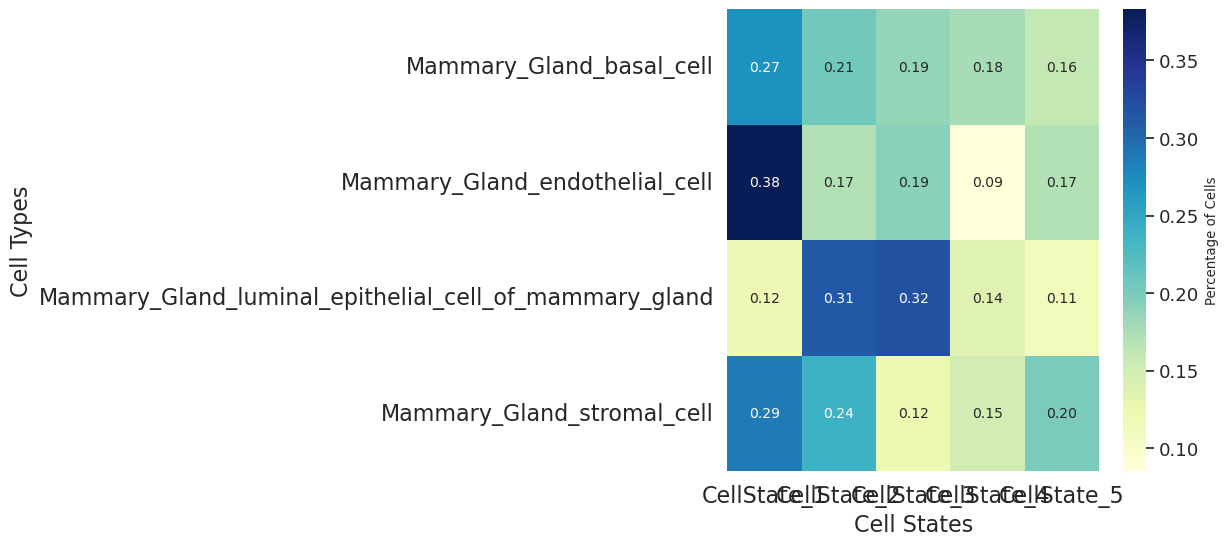

In [78]:
plt.figure(figsize=(6,6))
ax = sns.heatmap(contingency_table.T, annot=True, cmap="YlGnBu", fmt='.2f', annot_kws={"size": 10}, cbar_kws={'label': 'Percentage of Cells'})

# Further visual modifications
xlabel = plt.xlabel("Cell States", fontsize=16)
ylabel = plt.ylabel("Cell Types", fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Adjusting color bar settings
cbar = plt.gcf().axes[-1]
cbar.tick_params(labelsize=13)

plt.show()


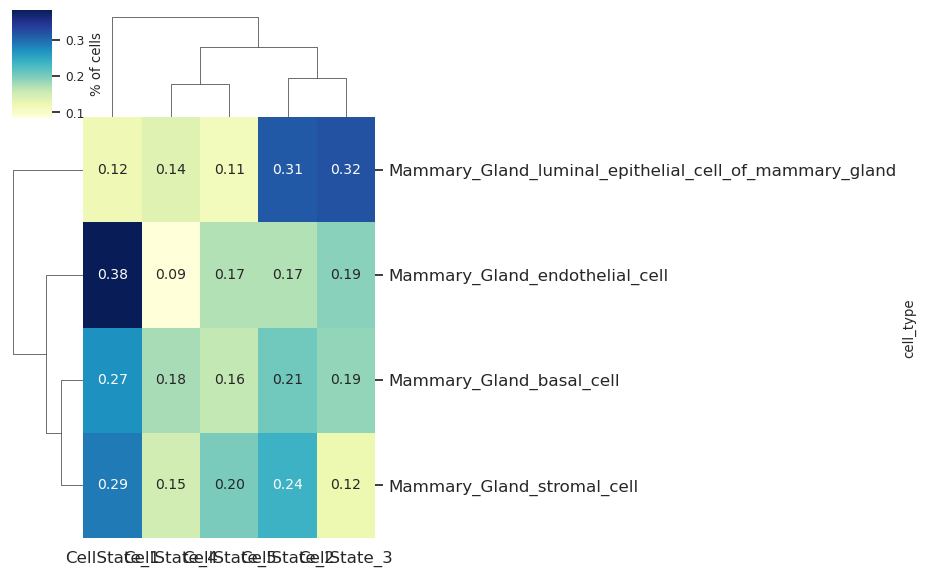

In [79]:
contingency_table

# plot clustermap of contingency table
g = sns.clustermap(contingency_table.T, cmap="YlGnBu", figsize=(8, 6), annot=True, fmt='.2f', annot_kws={"size": 10}, cbar_kws={'label': '% of cells'})
# Increase the font size of the x-axis and y-axis tick labels
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=12) # Set x-axis label size
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=12) # Set y-axis label size
# remove x lab 
g.ax_heatmap.set_xlabel("")

# Save the figure to a PDF file
plt.savefig("clustermap.pdf", bbox_inches='tight')

### Differential junction usage analysis